I just realized that the scattering surface seems to flare a lot more in the observations than it does in my models.
That's not great, but we can talk about this in the discussion (I don't want to redo all that stuff ;( and I also feel like Kees could have said something about this? I can't know everything.)
# AAAAAA

We now want to see if we can obtain a scattering surface that matches the observations (at least approximately) with these reasonable values that we have determined.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 13
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [89]:
# Load surface densities.
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion" ]

model_ind = 1

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [90]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

In [91]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
philist = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, philist, indexing='ij')

[0.86631022 1.15024764]
[2.80528639 3.4943041 ]


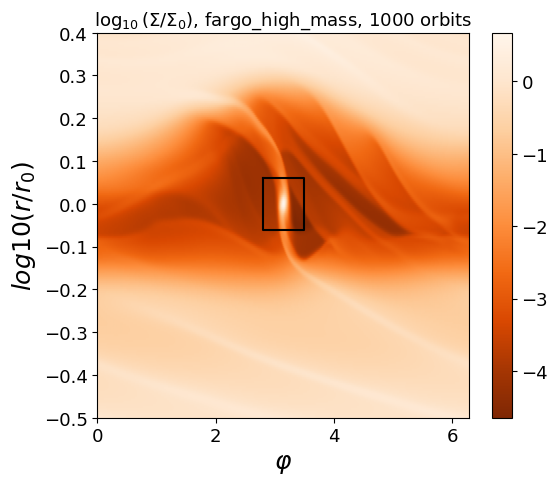

In [92]:
### Cutting out a piece

%matplotlib inline
r_min = 0.3
r_max = 7

r_cut = [101,128]
phi_cut = [171,213]
r_in_log = np.log10(r_list[r_cut[1]])
r_out_log = np.log10(r_list[r_cut[0]])
phi_left = philist[phi_cut[0]]
phi_right = philist[phi_cut[1]]


lim = 0.5

plt.figure(figsize=(6,5))
frame = 100

for it,i in enumerate([model_ind]):
    path = paths[i]
        
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])#,clim = (np.log10(lim+0.01),np.log10(lim-0.01)))
    plt.plot([phi_left, phi_right, phi_right, phi_left, phi_left],[r_in_log,r_in_log, r_out_log, r_out_log, r_in_log], color="k")
    
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(-0.5,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

print(r_list[r_cut])
print(philist[phi_cut])

(10, 4, 300, 384)


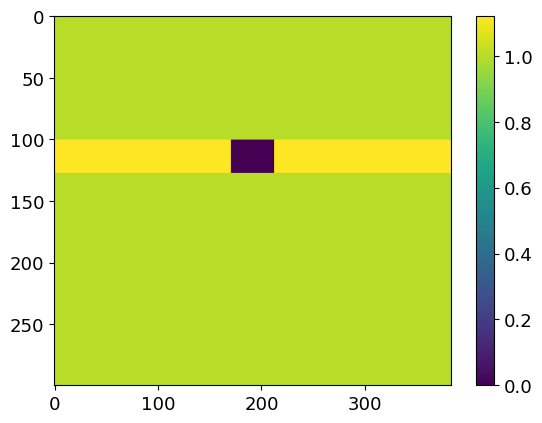

(10, 4, 300, 384)
(10, 4, 300)


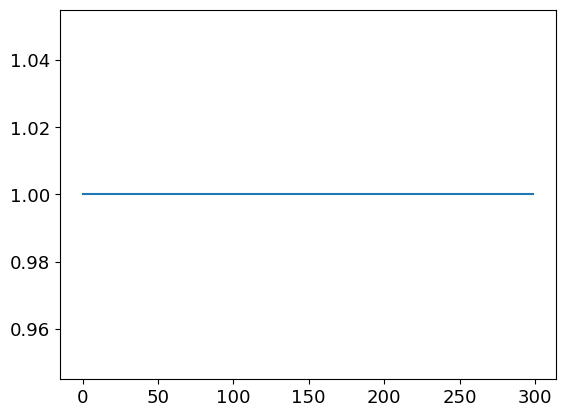

In [93]:


#rho_slice_mean = np.mean(rho_slice, axis=3)
mask = np.ones(rho_cube.shape)
print(mask.shape)
mask[:,:,r_cut[0]:r_cut[1]] = len(philist)/(len(philist)-(phi_cut[1]-phi_cut[0]))
mask[:,:,r_cut[0]:r_cut[1],phi_cut[0]:phi_cut[1]] = 0
plt.imshow(mask[1][0], aspect="auto")
plt.colorbar()
plt.show()

print(mask.shape)
print(np.mean(mask, axis=3).shape)
plt.plot(np.mean(mask, axis=3)[0][0])


rho_mean_clean = np.mean(rho_cube*mask, axis=3)
rho_mean = np.mean(rho_cube, axis=3)

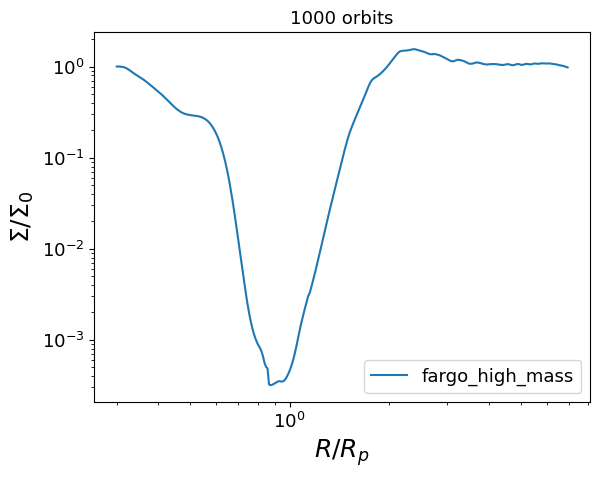

In [94]:

plt.plot(r_list,rho_mean_clean[model_ind][-1]/rho_mean[i][0],label=f"{path[43:-5]}")
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

In [116]:
# Note: all recycled from radmc3d.

au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi

# Star parameters
# taken from van capelleveen paper. Not the same as default!
mstar    = 1.0*ms#2.4*ms
rstar    = 1.418*rs#2.4*rs
tstar    = 4400#1e4
pstar    = np.array([0.,0.,0.])

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]

r0       = 57*au    # The radius corresponding to '1' in dimensionless units
rc = r_list*r0

scale_down = 5e-2


dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
#sigma_gas_2d   = np.ones([r_res,phi_res])*sigma_0
sigma_gas_1d   = rho_mean_clean[model_ind][-1]*scale_down
sigma_dust_1d = sigma_gas_1d*dtg_smalldust

#r_2d,phi_2d = np.meshgrid(rc,phic,indexing='ij')

Text(0, 0.5, '$\\Sigma_{dust}$ [g/cm²]')

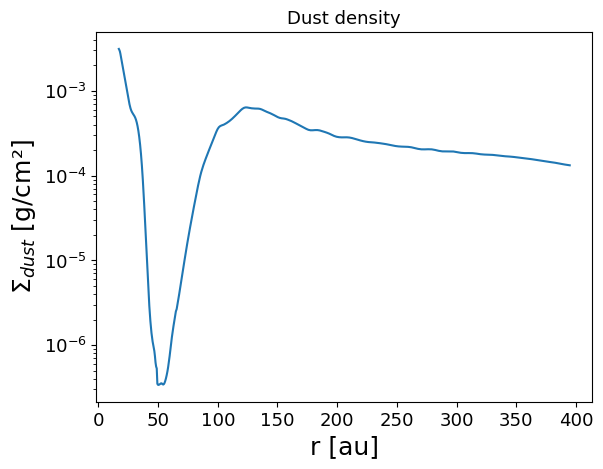

In [117]:

"""
Just a plot to check the density
"""
plt.plot(rc/au, sigma_dust_1d)
plt.yscale("log")
plt.xlabel("r [au]")
plt.title("Dust density")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")

In [118]:
#
# Now make a simple analytical disk model roughly along the
# lines of Chiang & Goldreich (1997), but with just a single
# vertical layer and with a constant radiative incidence angle.
#

"""
How are the incidence angle and the flaring index/aspect ratio related?

The incidence angle is given by alpha = h/r -dh/dr (according to armitage's book). So it will depend on r for a flared disk!

Also, we're assuming here that the disk radiates as a black body and is vertially isothermal. (In particular there's no dust
in the way)

What is a reasonable value for flang?
It's not really self-consistent to choose a constant value for it . . .

"""
r_1d=rc
r=rc
flang    = 0.05                        # The assumed constant radiative incidence angle
lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
hp       = cs/omk                      # The pressure scale height
hpr      = hp/rc                        # The dimensionless hp

#
# Compare the results to the AspectRatio and FlaringIndex of
# the FARGO3D setup. Note that we compute them using a simple
# Chiang & Goldreich like model, but this also has a free
# parameter: flang (the incidence angle). Since we keep this
# angle constant, the FlaringIndex should be 0.25, because
# T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
# so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
#
AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
print('If these values are vastly different from those in the FARGO3D .par file,')
print('you should either modify the parameters in the RADMC-3D model, or the parameters')
print('in the FARGO3D model, to make them both mutually self-consistent.')

Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.07183787192780985
  FlaringIndex in RADMC-3D model at R0 = 0.2503303526288863
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


By playing with this i noticed that the flaring index doesn't depend much on the incidence angle. The incidence angle mostly changes the aspect ratio.

In [119]:
omk_1d      = np.sqrt(GG*mstar/r_1d**3)  # The Kepler frequency Omega_K in 1/s
cs_1d = cs  # The isothermal sound speed c_s in cm/s
hp_1d       = cs_1d/omk_1d               # The press scale height H_p = c_s / Omega_K in cm
hpr_1d      = hp_1d/r_1d                 # The aspect ratio H_p / r
vth_1d      = np.sqrt(8/np.pi)*cs_1d     # The thermal velocity of H2 gas particles in cm/s
rho_gas_mid_1d = sigma_gas_1d/(np.sqrt(2*pi)*hp_1d)  # Midplane gas density in g/cm^3


# No idea if this is a good value.
thetaup = 0.1
ntheta   = 100
thetac   = np.linspace(thetaup,0.5e0*np.pi,ntheta)

# Make the 3-D grid
#
qq       = np.meshgrid(rc,thetac,indexing='ij')
rr       = qq[0]
tt       = qq[1]
zr       = np.pi/2.e0 - qq[1]

#
# For later vertical normalization: the Delta z
# (we integrate along theta, i.e. not exactly vertical)
#
#dz       = zr[:,:-1]*rr[:,:-1]-zr[:,1:]*rr[:,1:]

#
# Expand the 2-D gas model to 3-D
#
sigma_gas_3d  = np.zeros_like(rr)
hh_3d         = np.zeros_like(rr)
hhr_3d        = np.zeros_like(rr)
sigma_dust_3d  = np.zeros_like(rr)

for it in range(ntheta):
    sigma_gas_3d[:,it]= sigma_gas_1d[:]
    sigma_dust_3d[:,it] = sigma_dust_1d[:]
    hh_3d[:,it]        = hp_1d[:]
    hhr_3d[:,it]       = hpr_1d[:]
rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

#
# Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
#

rho_dust_3d = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

(300, 100)


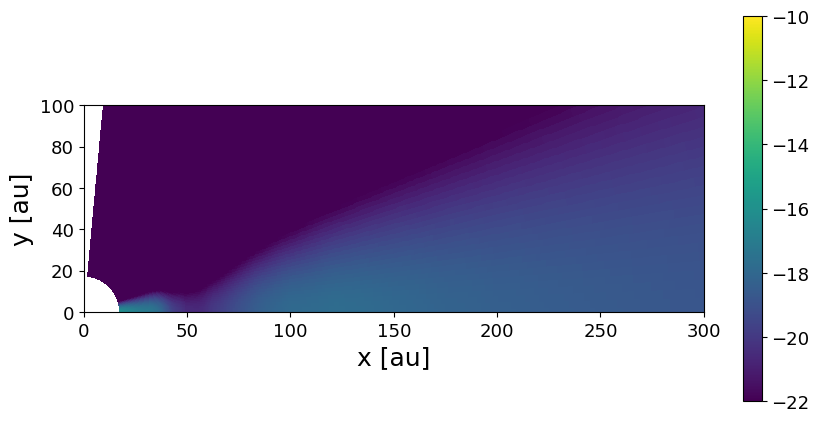

In [120]:
#plt.imshow(np.transpose(rho_dust_3d), origin="upper")
print(np.shape(rho_gas_3d))
plt.figure(figsize=(10,5))
rr, phiphi = np.meshgrid(rc,thetac)
yy = rr*np.cos(phiphi)
xx = rr*np.sin(phiphi)
plt.pcolormesh(xx/au, yy/au,np.transpose(np.log10(rho_dust_3d)), clim=(-22,-10))
plt.xlabel("x [au]")
plt.ylabel("y [au]")
plt.xlim(0,300)
plt.ylim(0,100)
plt.colorbar()
plt.gca().set_aspect("equal")

In [121]:
optical_depth_K = np.zeros_like(rho_dust_3d)
optical_depth_H = np.zeros_like(rho_dust_3d)
kappa_K = 327.86636079024055 # that's kappa_tot_K in cm²/g
kappa_H = 946.506869910016 #g/cm², now for the H-Band
for i in range(len(thetac)):
    # density along line of sight
    dens= 0
    for j in range(len(rc)):
        if j==0 or j==len(rc)-1:
            continue
        # Is this the correct dr???
        dens += rho_dust_3d[j][i]*(rc[j+1]-rc[j-1])*0.5
        optical_depth_K[j][i] = dens*kappa_K
        optical_depth_H[j][i] = dens*kappa_H

(300, 100)


/scratch/2399598/ipykernel_3544714/3300210672.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(xx/au, yy/au,np.transpose(np.log10(optical_depth_H)), clim=(-5,10))


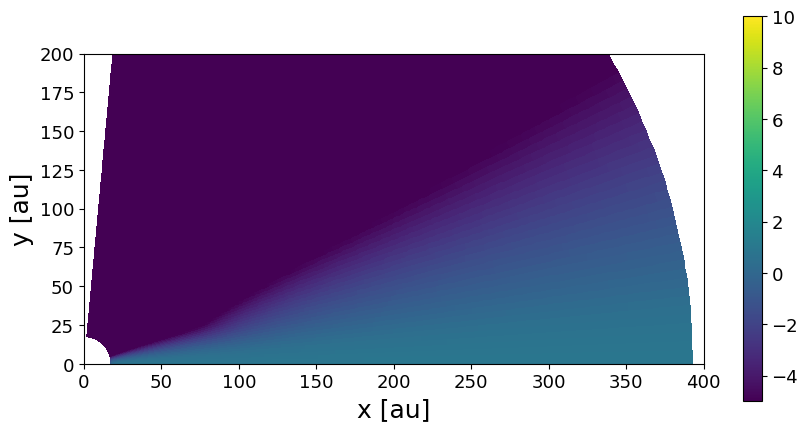

In [122]:
#plt.imshow(np.transpose(optical_depth_H))

#plt.imshow(np.transpose(rho_dust_3d), origin="upper")
print(np.shape(rho_gas_3d))
plt.figure(figsize=(10,5))
rr, phiphi = np.meshgrid(rc,thetac)
yy = rr*np.cos(phiphi)
xx = rr*np.sin(phiphi)
plt.pcolormesh(xx/au, yy/au,np.transpose(np.log10(optical_depth_H)), clim=(-5,10))
#plt.pcolormesh(xx/au, yy/au,np.transpose(optical_depth_H), clim=(0,100))
plt.xlabel("x [au]")
plt.ylabel("y [au]")
plt.xlim(0,400)
plt.ylim(0,200)
plt.colorbar()
plt.gca().set_aspect("equal")

In [123]:
tau_list = [0.1,1,10]
r_list_H =[]
r_list_K =[]
for t in tau_list:
    r_list_H.append([])
    r_list_K.append([])
    for i in range(len(thetac)):
        r_ = np.interp(t,optical_depth_H[1:-1,i], rc[1:-1])
        r_list_H[-1].append(r_)
        r_ = np.interp(t,optical_depth_K[1:-1,i], rc[1:-1])
        r_list_K[-1].append(r_)
r_list_H = np.array(r_list_H)
r_list_K = np.array(r_list_K)

Text(0.5, 1.0, 'Scattering surface K-band')

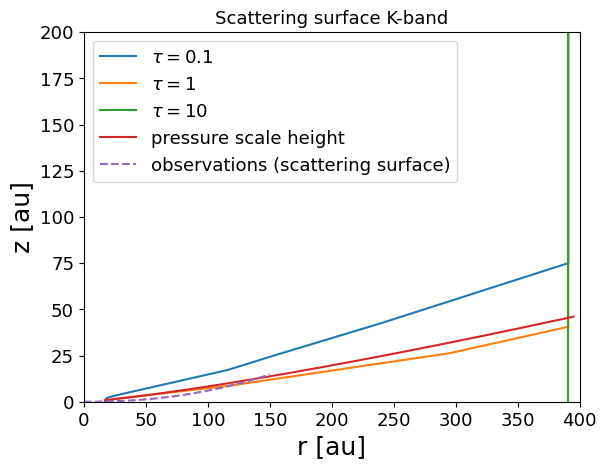

In [124]:
for i in range(len(tau_list)):
    plt.plot(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, label=f"$\\tau= {tau_list[i]}$")

plt.xlabel("r [au]")
plt.ylabel("z [au]")

plt.plot(rc/au, hp/au, label="pressure scale height")

r_ = np.linspace(0,150,100)
plt.plot(r_, r_*0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed")
plt.legend()
#plt.axis("equal")
plt.xlim(0,400)
plt.ylim(0,200)
plt.title("Scattering surface K-band")


/scratch/2399598/ipykernel_3544714/3956103090.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(xx/au, yy/au,np.transpose(np.log10(optical_depth_K)), clim=(-5,10), cmap="grey")


Text(0.5, 1.0, 'Scattering surface K-band')

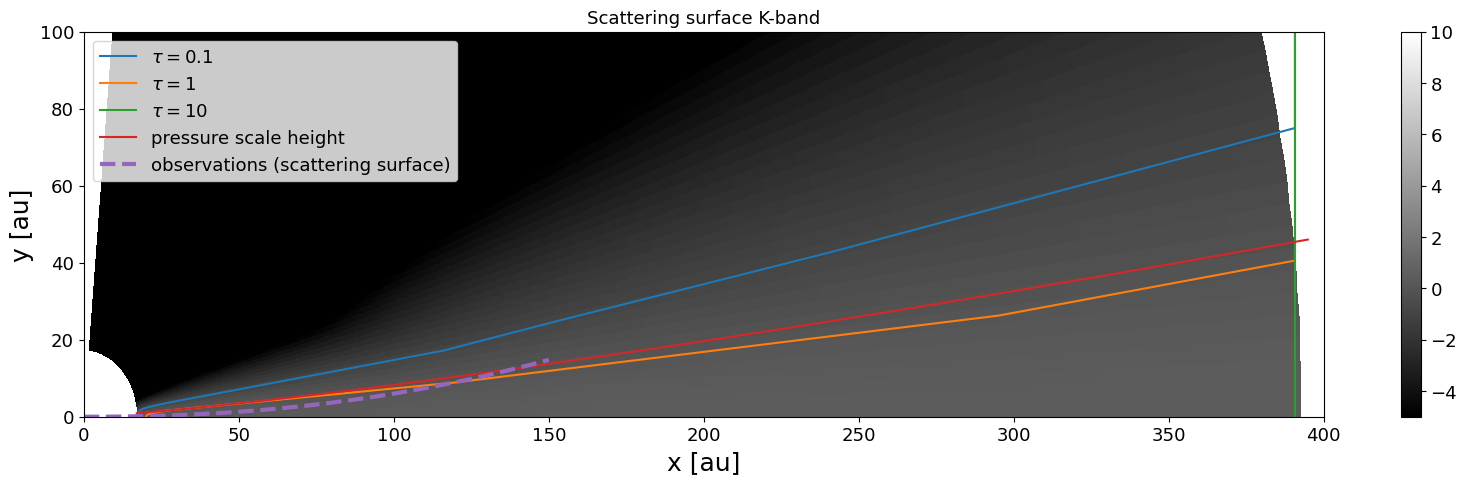

In [125]:

plt.figure(figsize=(20,5))

for i in range(len(tau_list)):
    plt.plot(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, label=f"$\\tau= {tau_list[i]}$")
plt.plot(rc/au, hp/au, label="pressure scale height")

r_ = np.linspace(0,150,100)
plt.plot(r_, r_*0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed", linewidth=3)


rr, phiphi = np.meshgrid(rc,thetac)
yy = rr*np.cos(phiphi)
xx = rr*np.sin(phiphi)
plt.pcolormesh(xx/au, yy/au,np.transpose(np.log10(optical_depth_K)), clim=(-5,10), cmap="grey")

plt.xlabel("x [au]")
plt.ylabel("y [au]")
plt.xlim(0,400)
plt.ylim(0,100)
plt.colorbar()
#plt.gca().set_aspect("equal")
plt.legend()
plt.title("Scattering surface K-band")


Text(0.5, 1.0, 'Scattering surface H-band')

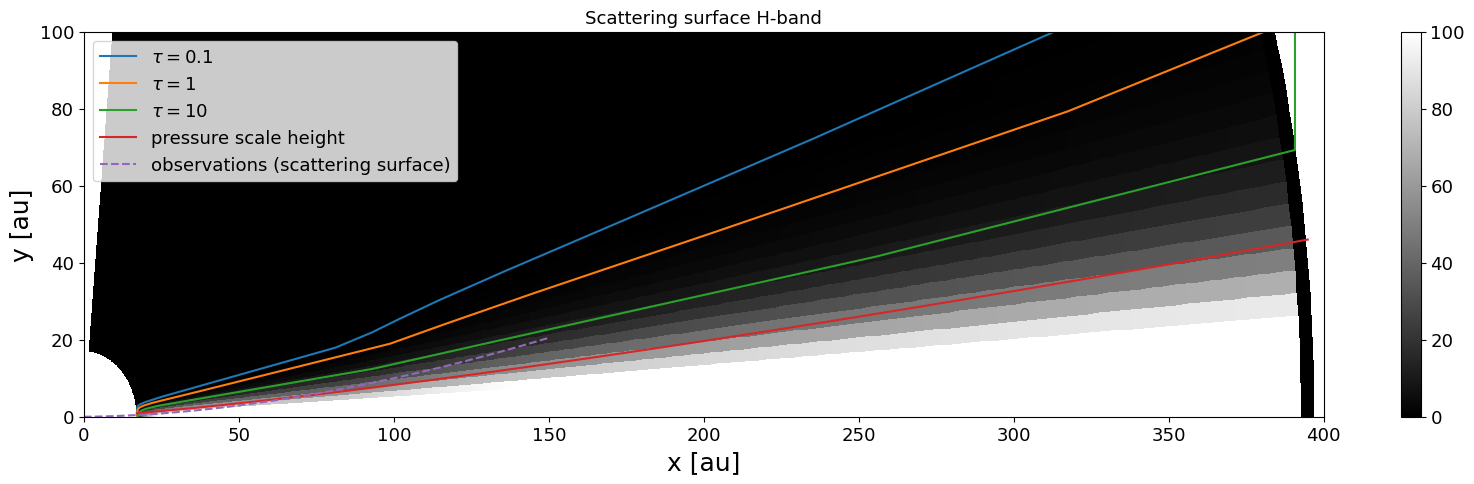

In [88]:
plt.figure(figsize=(20,5))

for i in range(len(tau_list)):
    plt.plot(r_list_H[i]/au, np.cos(thetac)*r_list_H[i]/au, label=f"$\\tau= {tau_list[i]}$")

plt.xlabel("r [au]")
plt.ylabel("z [au]")

plt.plot(rc/au, hp/au, label="pressure scale height")

r_ = np.linspace(0,150,100)
plt.plot(r_, r_*0.10*np.power(r_/100, 0.77), label="observations (scattering surface)", linestyle="dashed")
rr, phiphi = np.meshgrid(rc,thetac)
yy = rr*np.cos(phiphi)
xx = rr*np.sin(phiphi)
#plt.pcolormesh(xx/au, yy/au,np.transpose(np.log10(optical_depth_H)), clim=(-5,10), cmap="grey")
plt.pcolormesh(xx/au, yy/au,np.transpose(optical_depth_H), clim=(0,100), cmap="grey")

plt.xlabel("x [au]")
plt.ylabel("y [au]")
plt.xlim(0,400)
plt.ylim(0,100)
plt.colorbar()
#plt.gca().set_aspect("equal")
plt.legend()
plt.title("Scattering surface H-band")

/scratch/2045982/ipykernel_2368254/744261609.py:17: RuntimeWarning: invalid value encountered in divide
  plt.plot(r_surf/au, dz/dr-z_surf/r_surf)


(0.0, 200.0)

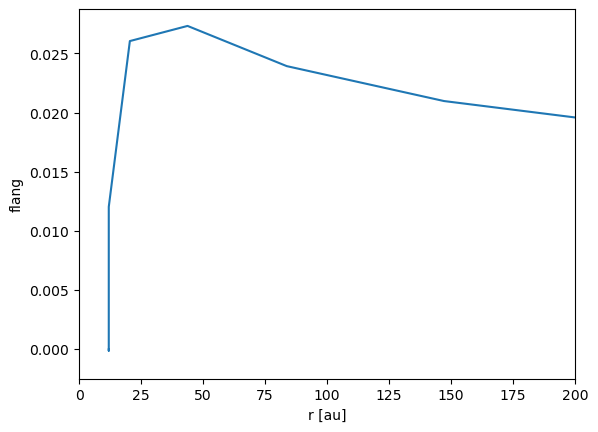

In [13]:
# We try to calculate flang, to see if our model is self-consistent.

r_surf = r_list_K[1]
theta_surf = thetac

z_surf = r_surf*np.cos(theta_surf)

dz = np.zeros_like(z_surf)
dr = np.zeros_like(r_surf)
for i in range(len(z_surf)):
    if i==0 or i==len(z_surf)-1: 
        continue
    dz[i] = 0.5*(z_surf[i-1]+z_surf[i+1])
    dr[i] = 0.5*(r_surf[i-1]+r_surf[i+1])


plt.plot(r_surf/au, dz/dr-z_surf/r_surf)
plt.xlabel("r [au]")
plt.ylabel("flang")
plt.xlim(0,200)

## Now, we try to make it easier to change variables like Sigma_0 etc.

In [14]:
def make_model(sigma_0 = 1.7e3, #g/cm²,
              sigma_slope=0,
              flang    = 0.05                        # The assumed constant radiative incidence angle,
    ):

    print("INPUT:")
    print(f"sigma_0: {sigma_0} g/cm² \nsigma_slope : {sigma_slope}\nflang: {flang}\n------")
    # Note: all recycled from radmc3d.
    
    au  = 1.49598e13     # Astronomical Unit       [cm]
    pc  = 3.08572e18     # Parsec                  [cm]
    ms  = 1.98892e33     # Solar mass              [g]
    ts  = 5.78e3         # Solar temperature       [K]
    ls  = 3.8525e33      # Solar luminosity        [erg/s]
    rs  = 6.96e10        # Solar radius            [cm]
    ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
    kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
    mp  = 1.6726e-24     # Mass of proton          [g]
    GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
    pi  = np.pi          # Pi
    
    # Star parameters
    # taken from van capelleveen paper. Not the same as default!
    mstar    = 1.08*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4
    pstar    = np.array([0.,0.,0.])
    
    
    r0       = 57*au    # The radius corresponding to '1' in dimensionless units
    r_res = 1000
    rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
        
    dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
    #sigma_gas_2d   = np.ones([r_res,phi_res])*sigma_0
    sigma_gas_1d   = np.power(rc/r0,-sigma_slope)*sigma_0
    sigma_dust_1d = sigma_gas_1d*dtg_smalldust

    r_1d=rc
    r=rc
    
    lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
    firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
    tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
    cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
    omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
    hp       = cs/omk                      # The pressure scale height
    hpr      = hp/rc                        # The dimensionless hp
    
    #
    # Compare the results to the AspectRatio and FlaringIndex of
    # the FARGO3D setup. Note that we compute them using a simple
    # Chiang & Goldreich like model, but this also has a free
    # parameter: flang (the incidence angle). Since we keep this
    # angle constant, the FlaringIndex should be 0.25, because
    # T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
    # so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
    #
    AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
    flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
    FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
    print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
    print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
    print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
    print('If these values are vastly different from those in the FARGO3D .par file,')
    print('you should either modify the parameters in the RADMC-3D model, or the parameters')
    print('in the FARGO3D model, to make them both mutually self-consistent.')

    omk_1d      = np.sqrt(GG*mstar/r_1d**3)  # The Kepler frequency Omega_K in 1/s
    cs_1d = cs  # The isothermal sound speed c_s in cm/s
    hp_1d       = cs_1d/omk_1d               # The press scale height H_p = c_s / Omega_K in cm
    hpr_1d      = hp_1d/r_1d                 # The aspect ratio H_p / r
    vth_1d      = np.sqrt(8/np.pi)*cs_1d     # The thermal velocity of H2 gas particles in cm/s
    rho_gas_mid_1d = sigma_gas_1d/(np.sqrt(2*pi)*hp_1d)  # Midplane gas density in g/cm^3
    
    
    # No idea if this is a good value.
    thetaup = 0.1
    ntheta   = 1000
    thetac   = np.linspace(thetaup,0.5e0*np.pi,ntheta)
    
    # Make the 3-D grid
    #
    qq       = np.meshgrid(rc,thetac,indexing='ij')
    rr       = qq[0]
    tt       = qq[1]
    zr       = np.pi/2.e0 - qq[1]
    
    #
    # For later vertical normalization: the Delta z
    # (we integrate along theta, i.e. not exactly vertical)
    #
    #dz       = zr[:,:-1]*rr[:,:-1]-zr[:,1:]*rr[:,1:]
    
    #
    # Expand the 2-D gas model to 3-D
    #
    sigma_gas_3d  = np.zeros_like(rr)
    hh_3d         = np.zeros_like(rr)
    hhr_3d        = np.zeros_like(rr)
    sigma_dust_3d  = np.zeros_like(rr)
    
    for it in range(ntheta):
        sigma_gas_3d[:,it]= sigma_gas_1d[:]
        sigma_dust_3d[:,it] = sigma_dust_1d[:]
        hh_3d[:,it]        = hp_1d[:]
        hhr_3d[:,it]       = hpr_1d[:]
    rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
    
    #
    # Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
    #
    
    rho_dust_3d = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

    return rho_dust_3d, rc, thetac,hp,flang

In [ ]:

"""for j in range(len(rc)):
            
            if j==0:
                dens += rho_dust_3d[j][i]*(rc[j])
            elif j==len(rc)-1:
                dens += rho_dust_3d[j][i]*(rc[j]-rc[j-1])
            else:
                # Is this the correct dr???
                dens += rho_dust_3d[j][i]*(rc[j+1]-rc[j-1])*0.5
            optical_depth_K[j][i] = dens*kappa_K
            optical_depth_H[j][i] = dens*kappa_H"""

In [50]:
def make_scat(rho_dust_3d, rc, thetac,hp, flang):
    au  = 1.49598e13     # Astronomical Unit       [cm]
    optical_depth_K = np.zeros_like(rho_dust_3d)
    optical_depth_H = np.zeros_like(rho_dust_3d)
    kappa_K = 327.86636079024055 # cm²/g for the K band
    kappa_H = 946.506869910016 #cm²/g, now for the H-Band
    for i in range(len(thetac)):
        # density along line of sight
        dens= 0
        for j in range(len(rc)):
            if j==0:
                dens += rho_dust_3d[j][i]*(rc[j])
            elif j==len(rc)-1:
                dens += rho_dust_3d[j][i]*(rc[j]-rc[j-1])
            else:
                # Is this the correct dr???
                dens += rho_dust_3d[j][i]*(rc[j+1]-rc[j-1])*0.5
            optical_depth_K[j][i] = dens*kappa_K
            optical_depth_H[j][i] = dens*kappa_H
            
    tau_list = [0.1,1,10]
    r_list_H =[]
    r_list_K =[]
    for t in tau_list:
        r_list_H.append([])
        r_list_K.append([])
        for i in range(len(thetac)):
            r_ = np.interp(t,optical_depth_H[1:-1,i], rc[1:-1])
            r_list_H[-1].append(r_)
            r_ = np.interp(t,optical_depth_K[1:-1,i], rc[1:-1])
            r_list_K[-1].append(r_)
    r_list_H = np.array(r_list_H)
    r_list_K = np.array(r_list_K)

    #### Now plot ####
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for i in range(len(tau_list)):
        plt.scatter(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, s=10, marker="x")
        plt.plot(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, label=f"$\\tau= {tau_list[i]}$")
        
    plt.xlabel("r [au]")
    plt.ylabel("z [au]")
    
    plt.plot(rc/au, hp/au, label="pressure scale height")
    
    r_ = np.linspace(0,150,100)
    plt.plot(r_, r_*0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(0,400)
    plt.ylim(0,200)
    plt.title("Scattering surface K-band")

    plt.subplot(1,2,2)

    for i in range(len(tau_list)):
        plt.scatter(r_list_H[i]/au, np.cos(thetac)*r_list_H[i]/au, s=10, marker="x")
        plt.plot(r_list_H[i]/au, np.cos(thetac)*r_list_H[i]/au, label=f"$\\tau= {tau_list[i]}$")
    
    plt.xlabel("r [au]")
    plt.ylabel("z [au]")
    
    plt.plot(rc/au, hp/au, label="pressure scale height")
    
    r_ = np.linspace(0,300,100)
    plt.plot(r_, r_*0.10*np.power(r_/100, 0.77), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(0,400)
    plt.ylim(0,200)
    plt.title("Scattering surface H-band")

    plt.show()



    ###########
#### Now plot ####
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for i in range(len(tau_list)):
        plt.scatter(r_list_K[i]/au, np.cos(thetac), s=10, marker="x")
        plt.plot(r_list_K[i]/au, np.cos(thetac), label=f"$\\tau= {tau_list[i]}$")
        
    plt.xlabel("r [au]")
    plt.ylabel("z&r [au]")
    
    plt.plot(rc/au, hp/rc, label="pressure scale height")
    
    r_ = np.linspace(0,150,100)
    plt.plot(r_, 0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(4,400)
    #plt.ylim(0,1)
    plt.xscale("log")
    plt.title("Scattering surface K-band")

    plt.subplot(1,2,2)

    for i in range(len(tau_list)):
        plt.scatter(r_list_H[i]/au, np.cos(thetac), s=10, marker="x")
        plt.plot(r_list_H[i]/au, np.cos(thetac), label=f"$\\tau= {tau_list[i]}$")
    
    plt.xlabel("r [au]")
    plt.ylabel("z&r [au]")
    
    plt.plot(rc/au, hp/rc, label="pressure scale height")

    r_ = np.linspace(0,300,100)
    plt.plot(r_, 0.10*np.power(r_/100, 0.77), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(4,400)
    plt.xscale("log")
    #plt.ylim(0,1)
    plt.title("Scattering surface H-band")

    plt.show()
    
    #### Plot to compare flang

    # We try to calculate flang, to see if our model is self-consistent.

    r_surf = r_list_H[1]
    theta_surf = thetac
    
    z_surf = r_surf*np.cos(theta_surf)
    
    dz = np.zeros_like(z_surf)
    dr = np.zeros_like(r_surf)
    for i in range(len(z_surf)):
        if i==0 or i==len(z_surf)-1: 
            continue
        dz[i] = 0.5*(z_surf[i-1]+z_surf[i+1])
        dr[i] = 0.5*(r_surf[i-1]+r_surf[i+1])
    
    
    plt.plot(r_surf/au, dz/dr-z_surf/r_surf, label="from scattering surface")
    plt.plot(r_surf/au, np.ones_like(r_surf)*flang, label="input")
    plt.xlabel("r [au]")
    plt.ylabel("flang")
    plt.legend()
    #plt.xlim(0,200)

    r_surf = r_surf[1:-1]
    z_surf = z_surf[1:-1]
    dr = dr[1:-1]
    dz = dz[1:-1]
    
    flang_like = []
    for r_ in rc:
        flang_like.append(np.interp(r_, r_surf,  dz/dr-z_surf/r_surf))

    return flang_like

INPUT:
sigma_0: 0.3 g/cm² 
sigma_slope : -1
flang: 0.1
------
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.0753826193948975
  FlaringIndex in RADMC-3D model at R0 = 0.24968493690645638
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


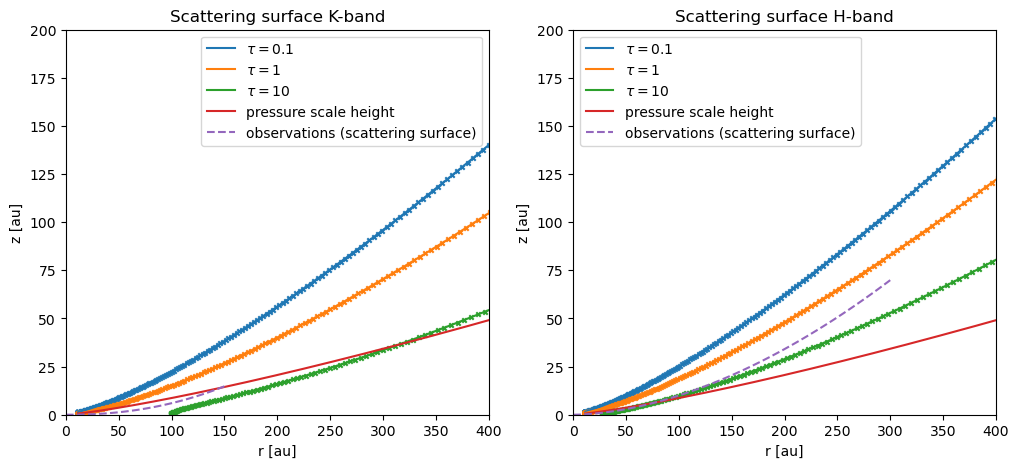

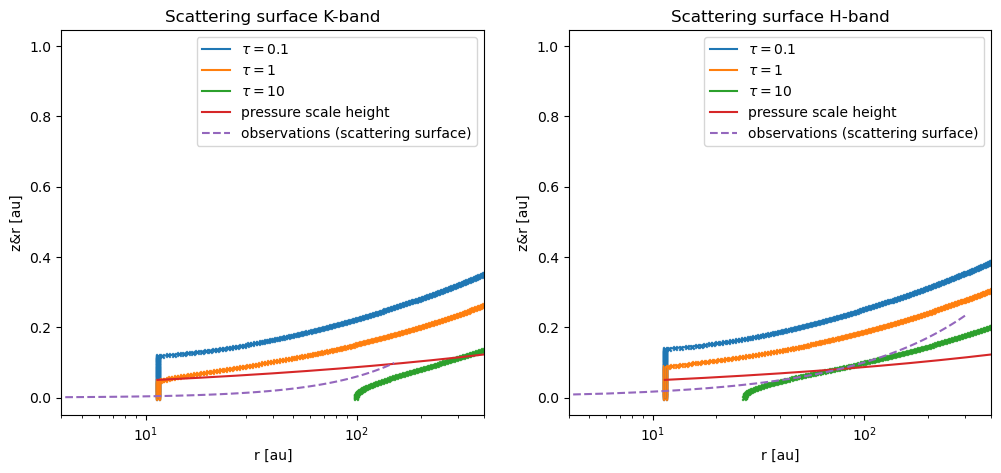

/scratch/2045982/ipykernel_2368254/4272203574.py:140: RuntimeWarning: invalid value encountered in divide
  plt.plot(r_surf/au, dz/dr-z_surf/r_surf, label="from scattering surface")


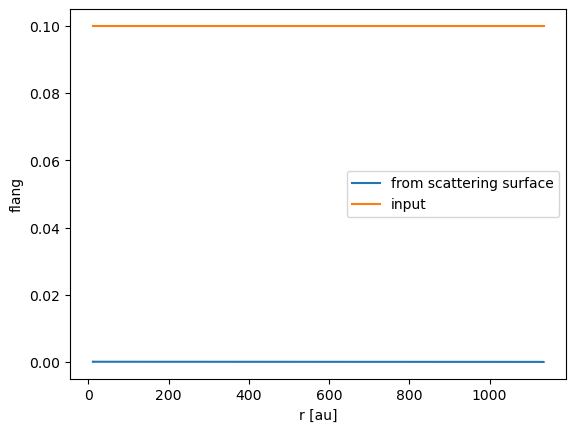

In [59]:
rho_dust_3d, rc, thetac,hp, flang = make_model(sigma_0 = 0.3, #g/cm²,
                                               sigma_slope=-1,flang    = 0.1 )
flang_like = make_scat(rho_dust_3d, rc, thetac,hp, flang)

This is clearly not working well. Lowering sigma_0 is like scaling the scattering surfaces with a factor. Changing sigma slope has barely any effect at all. Maybe the incidence angle can be changed??
The slope of the observations can't really be matched with this model.

In [26]:
mstar    = 1.08*ms#2.4*ms
rstar    = 1.418*rs#2.4*rs
tstar    = 4400
lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity

lsun = 4*pi*rs**2*ss*6000**4

print(lstar/lsun)

0.5815113103012346


We abandon all physicality and try to force the correct temperature profile - by just setting the flaring index and the aspect ratio directly.

In [74]:
def make_model_no_flang(sigma_0 = 1.7e3, #g/cm²,
              sigma_slope=0,
            hp0 = 0.075, # aspect ratio at planet
            flaring_index = 0.25,
    ):

    print("INPUT:")
    print(f"sigma_0: {sigma_0} g/cm² \nsigma_slope : {sigma_slope}\nhp0 : {hp0}\nflaring_index : {flaring_index}\n------")
    # Note: all recycled from radmc3d.
    
    au  = 1.49598e13     # Astronomical Unit       [cm]
    pc  = 3.08572e18     # Parsec                  [cm]
    ms  = 1.98892e33     # Solar mass              [g]
    ts  = 5.78e3         # Solar temperature       [K]
    ls  = 3.8525e33      # Solar luminosity        [erg/s]
    rs  = 6.96e10        # Solar radius            [cm]
    ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
    kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
    mp  = 1.6726e-24     # Mass of proton          [g]
    GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
    pi  = np.pi          # Pi
    
    # Star parameters
    # taken from van capelleveen paper. Not the same as default!
    mstar    = 1.08*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4
    pstar    = np.array([0.,0.,0.])
    
    
    r0       = 57*au    # The radius corresponding to '1' in dimensionless units
    r_res = 1000
    rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
        
    dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
    #sigma_gas_2d   = np.ones([r_res,phi_res])*sigma_0
    sigma_gas_1d   = np.power(rc/r0,-sigma_slope)*sigma_0
    sigma_dust_1d = sigma_gas_1d*dtg_smalldust

    r_1d=rc
    r=rc
    """
    lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
    firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
    tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
    cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
    omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
    """
    hp       = rc*hp0*np.power(rc/r0, flaring_index)                      # The pressure scale height
    hpr      = hp/rc                        # The dimensionless hp
    
    #
    # Compare the results to the AspectRatio and FlaringIndex of
    # the FARGO3D setup. Note that we compute them using a simple
    # Chiang & Goldreich like model, but this also has a free
    # parameter: flang (the incidence angle). Since we keep this
    # angle constant, the FlaringIndex should be 0.25, because
    # T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
    # so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
    #
    AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
    flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
    FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
    print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
    print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
    print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
    print('If these values are vastly different from those in the FARGO3D .par file,')
    print('you should either modify the parameters in the RADMC-3D model, or the parameters')
    print('in the FARGO3D model, to make them both mutually self-consistent.')

    #omk_1d      = np.sqrt(GG*mstar/r_1d**3)  # The Kepler frequency Omega_K in 1/s
    #cs_1d = cs  # The isothermal sound speed c_s in cm/s
    hp_1d       = hp              # The press scale height H_p = c_s / Omega_K in cm
    hpr_1d      = hp_1d/r_1d                 # The aspect ratio H_p / r
    #vth_1d      = np.sqrt(8/np.pi)*cs_1d     # The thermal velocity of H2 gas particles in cm/s
    rho_gas_mid_1d = sigma_gas_1d/(np.sqrt(2*pi)*hp_1d)  # Midplane gas density in g/cm^3
    
    
    # No idea if this is a good value.
    thetaup = 0.1
    ntheta   = 1000
    thetac   = np.linspace(thetaup,0.5e0*np.pi,ntheta)
    
    # Make the 3-D grid
    #
    qq       = np.meshgrid(rc,thetac,indexing='ij')
    rr       = qq[0]
    # Star parameters
    # taken from van capelleveen paper. Not the same as default!
    mstar    = 1.0*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4    tt       = qq[1]
    zr       = np.pi/2.e0 - qq[1]
    
    #
    # For later vertical normalization: the Delta z
    # (we integrate along theta, i.e. not exactly vertical)
    #
    #dz       = zr[:,:-1]*rr[:,:-1]-zr[:,1:]*rr[:,1:]
    
    #
    # Expand the 2-D gas model to 3-D
    #
    sigma_gas_3d  = np.zeros_like(rr)
    hh_3d         = np.zeros_like(rr)
    hhr_3d        = np.zeros_like(rr)
    sigma_dust_3d  = np.zeros_like(rr)
    
    for it in range(ntheta):
        sigma_gas_3d[:,it]= sigma_gas_1d[:]
        sigma_dust_3d[:,it] = sigma_dust_1d[:]
        hh_3d[:,it]        = hp_1d[:]
        hhr_3d[:,it]       = hpr_1d[:]
    rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
    
    #
    # Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
    #
    
    rho_dust_3d = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
    
    return rho_dust_3d, rc, thetac,hp,np.nan

INPUT:
sigma_0: 0.17 g/cm² 
sigma_slope : 0
hp0 : 0.05
flaring_index : 0.7
------
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.04999998692723461
  FlaringIndex in RADMC-3D model at R0 = 0.6996469514234278
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


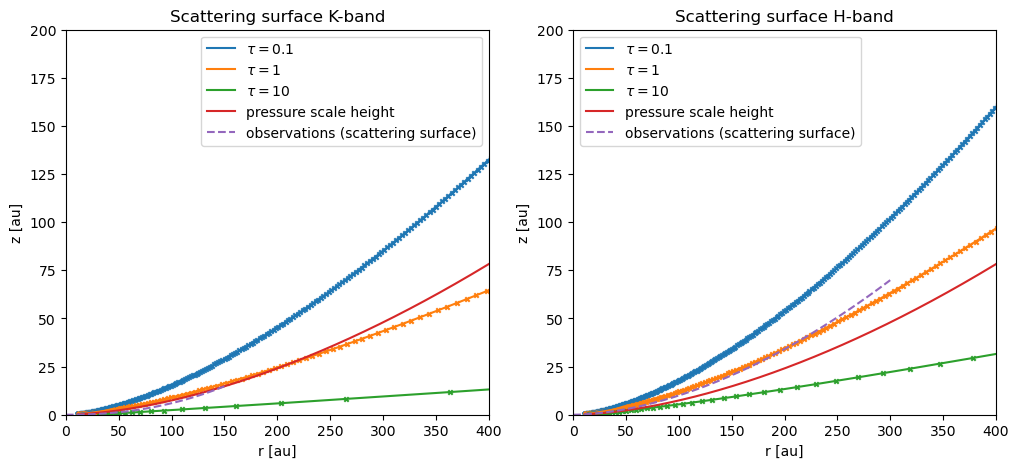

/scratch/2044498/ipykernel_2716118/3827152050.py:91: RuntimeWarning: invalid value encountered in divide
  plt.plot(r_surf/au, dz/dr-z_surf/r_surf, label="from scattering surface")


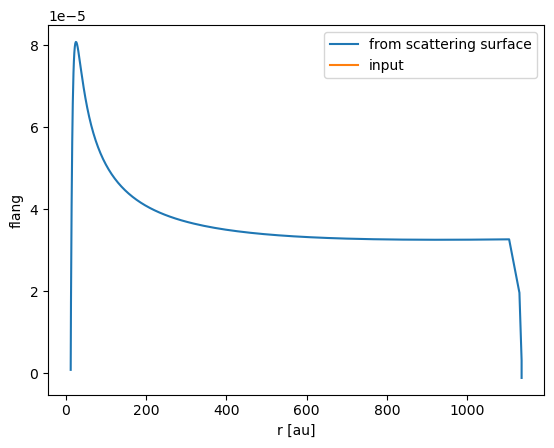

In [75]:
rho_dust_3d, rc, thetac,hp, flang = make_model_no_flang(sigma_0 = 1.7e-1, #g/cm²,
                                               sigma_slope=0,
                                              hp0 = 0.05, # aspect ratio at planet
                                                flaring_index = 0.7,)
flang_like = make_scat(rho_dust_3d, rc, thetac,hp, flang)

## What kind of impossible temperature profile would be required to create these values for the flaring index etc.?

In [103]:
au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi
    


def flaring_to_temp(sigma_0 = 1.7e3, #g/cm²,
                    sigma_slope=0,
                    hp0 = 0.05, # aspect ratio at planet
                    flaring_index = 0.7, flang=0.05):
    
    mstar    = 1.0*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4

    r0       = 57*au    # The radius corresponding to '1' in dimensionless units
    r_res = 1000
    rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
    hp       = rc*hp0*np.power(rc/r0, flaring_index)                      # The pressure scale height
    hpr      = hp/rc                        # The dimensionless hp

    T = hp**2*2.3*mp*GG*mstar/kk/rc**3

    lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
    firr     = flang*lstar/(4*pi*rc**2)     # Irradiative flux
    tmid     = (firr/ss)**0.25  
    
    plt.plot(rc/au, T, label="required temperature")
    plt.plot(rc/au, tmid, label="predicted temperature")
    plt.xlabel("r [au]")
    plt.ylabel("$T_{disk}$ [K]")
    plt.legend()
    plt.title(":(")

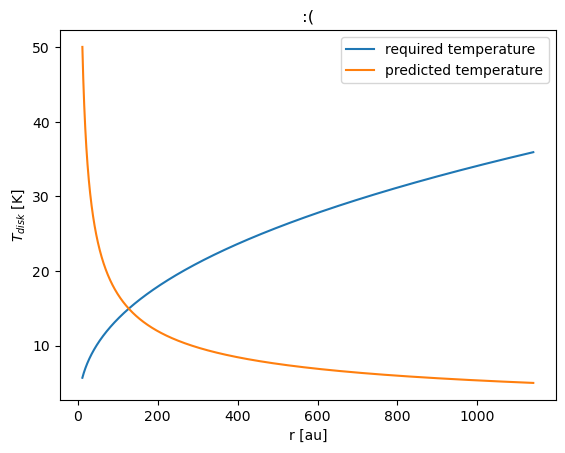

In [104]:
flaring_to_temp()

Conclusion: There is no way to match the observed scattering surfaces with this model for physically possible temperature profiles :(

Either the model is incorrect (implementation error, logical error), or the data is fishy.